| Deep Learning - Project 5|
|--------------------------|
| Sia Tedy |
| Unsupervised & Semi Supervised Learning|

# Project 5
## Unsupervised and Semi-Supervised Learning

### Learning Objectives
Students will learn to:
- Implement unsupervised learning algorithms
- Explore data structure without labels
- Apply semi-supervised learning strategies
- Analyze clustering and representation quality

## Part 1 - Conceptual Questions (1%)

**1. What is the difference between supervised and unsupervised learning?**  
In supervised learning, the model is trained using input data together with their correct labels, so the main goal is to learn a mapping from features to targets. In contrast, unsupervised learning works with unlabeled data and tries to discover hidden structure in the dataset, such as clusters, patterns, or compact feature representations.

**2. What is semi-supervised learning?**  
Semi-supervised learning is a setting between supervised and unsupervised learning. In this approach, we use a small portion of labeled data together with a larger amount of unlabeled data. The main idea is that unlabeled samples still contain useful information about the data distribution, and if we use them correctly, we can improve performance without manually labeling the entire dataset.

**3. Why are representation learning methods useful?**  
Representation learning methods are useful because they transform raw data into more informative and compact features. Good representations reduce noise, preserve the important structure of the data, and make downstream tasks such as clustering, visualization, and classification easier. In image problems, representation learning can help the model focus on shape, color, texture, and other meaningful visual properties instead of only relying on raw pixel values.

## Part 2 - Unsupervised Learning (3%)

For this project, I selected the **CIFAR-10** dataset. This dataset contains 10 object classes and is a good choice because it is complex enough to make clustering meaningful while still being small enough for experimentation in a notebook.

In this section, I use the following pipeline:
- Load and preprocess CIFAR-10 images
- Flatten the images and standardize the features
- Reduce dimensionality using **PCA**
- Apply **K-Means** clustering on the reduced representation
- Evaluate the clustering quality and visualize the clusters

I use PCA because it is simple, interpretable, and computationally efficient for an educational notebook. It helps preserve the main variance in the data while reducing the dimensionality enough for clustering and visualization.

100%|██████████| 170M/170M [00:06<00:00, 26.6MB/s] 


Unsupervised subset shape: (10000, 32, 32, 3)
Label distribution: Counter({np.int64(1): 1000, np.int64(0): 1000, np.int64(9): 1000, np.int64(6): 1000, np.int64(5): 1000, np.int64(8): 1000, np.int64(7): 1000, np.int64(4): 1000, np.int64(3): 1000, np.int64(2): 1000})
Total explained variance by 100 PCA components: 0.9001
Adjusted Rand Index (ARI): 0.0412
Normalized Mutual Information (NMI): 0.0791
Majority-vote cluster accuracy: 0.2223


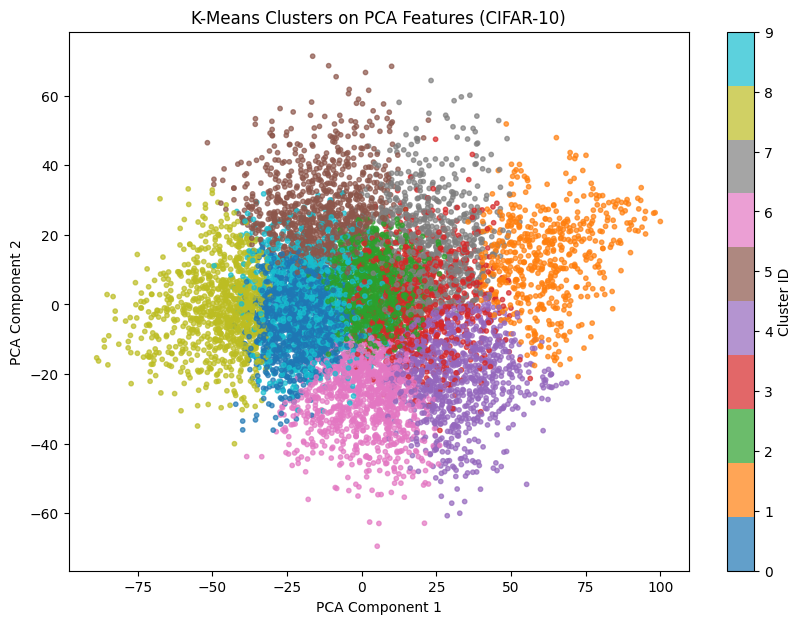

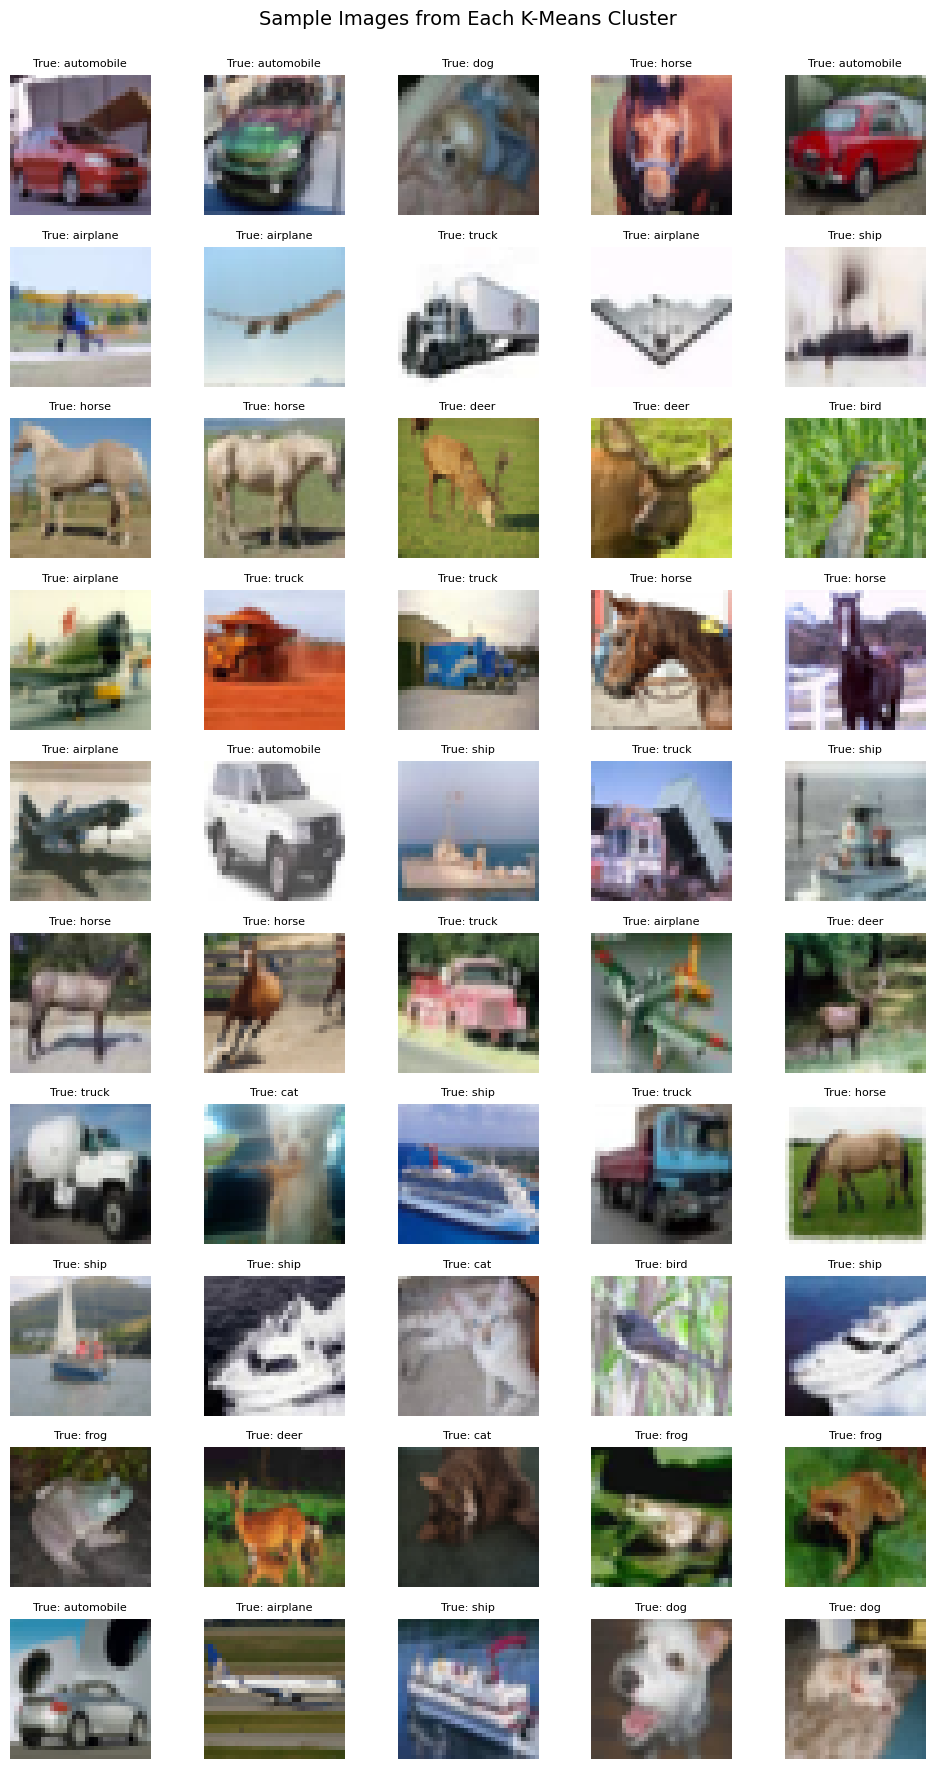

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from torchvision import datasets

# Set a fixed random seed to make the experiment reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Define the CIFAR-10 class names for readable plots and analysis.
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


def build_balanced_subset(data, targets, samples_per_class, random_state=42):
    """
    Create a balanced subset so that every class contributes the same number of samples.
    This makes clustering evaluation and visualization more stable and fair.
    """
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(targets):
        class_indices = np.where(targets == class_id)[0]
        chosen = rng.choice(class_indices, size=samples_per_class, replace=False)
        selected_indices.extend(chosen.tolist())

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)
    return data[selected_indices], targets[selected_indices]


def cluster_accuracy_from_majority_vote(y_true, y_cluster):
    """
    Estimate clustering quality by assigning each cluster the majority true label.
    This is not a perfect metric, but it gives an intuitive view of cluster purity.
    """
    total_correct = 0
    cluster_label_map = {}

    for cluster_id in np.unique(y_cluster):
        members = y_true[y_cluster == cluster_id]
        majority_label = Counter(members).most_common(1)[0][0]
        cluster_label_map[cluster_id] = majority_label
        total_correct += np.sum(members == majority_label)

    accuracy = total_correct / len(y_true)
    return accuracy, cluster_label_map


# Download CIFAR-10. The dataset will be stored locally in the project folder.
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True)

# Convert image objects into NumPy arrays for scikit-learn processing.
X_train_full = np.array(train_dataset.data)
y_train_full = np.array(train_dataset.targets)
X_test_full = np.array(test_dataset.data)
y_test_full = np.array(test_dataset.targets)

# Use a balanced subset to keep the notebook efficient while preserving all classes.
X_unsup, y_unsup = build_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=1000,
    random_state=RANDOM_STATE,
)

print('Unsupervised subset shape:', X_unsup.shape)
print('Label distribution:', Counter(y_unsup))

# Flatten 32x32x3 images into vectors because PCA and K-Means expect 2D tabular input.
X_unsup_flat = X_unsup.reshape(len(X_unsup), -1).astype(np.float32)

# Standardization improves PCA because each feature is put on a comparable scale.
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup_flat)

# Reduce the dimensionality before clustering.
# Keeping 100 components usually preserves a good amount of information.
pca_unsup = PCA(n_components=100, random_state=RANDOM_STATE)
X_unsup_pca = pca_unsup.fit_transform(X_unsup_scaled)

explained_variance = pca_unsup.explained_variance_ratio_.sum()
print(f'Total explained variance by 100 PCA components: {explained_variance:.4f}')

# Run K-Means with the number of clusters equal to the number of CIFAR-10 classes.
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=20)
cluster_ids = kmeans.fit_predict(X_unsup_pca)

# Evaluate clustering quality using common unsupervised metrics.
ari = adjusted_rand_score(y_unsup, cluster_ids)
nmi = normalized_mutual_info_score(y_unsup, cluster_ids)
majority_acc, cluster_label_map = cluster_accuracy_from_majority_vote(y_unsup, cluster_ids)

print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')
print(f'Majority-vote cluster accuracy: {majority_acc:.4f}')

# Project the PCA features to 2D for a quick cluster visualization.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_unsup_2d = pca_2d.fit_transform(X_unsup_pca)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_unsup_2d[:, 0],
    X_unsup_2d[:, 1],
    c=cluster_ids,
    cmap='tab10',
    s=10,
    alpha=0.7,
)
plt.title('K-Means Clusters on PCA Features (CIFAR-10)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# Show a few samples from each cluster to understand what the model grouped together.
fig, axes = plt.subplots(10, 5, figsize=(10, 18))
fig.suptitle('Sample Images from Each K-Means Cluster', fontsize=14)

for cluster_id in range(10):
    cluster_members = np.where(cluster_ids == cluster_id)[0]
    chosen_members = cluster_members[:5]

    for col in range(5):
        ax = axes[cluster_id, col]
        if col < len(chosen_members):
            idx = chosen_members[col]
            ax.imshow(X_unsup[idx])
            ax.set_title(f'True: {class_names[y_unsup[idx]]}', fontsize=8)
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Part 3 - Visualization (2%)

In this part, I use **t-SNE** to visualize the learned PCA representation in two dimensions. t-SNE is useful because it focuses on preserving local neighborhood relationships, which makes it effective for showing whether visually similar samples are grouped together.

When analyzing the plot, I expect to see that some classes are more separable than others. For example, classes such as **ship**, **truck**, and **airplane** often form relatively clearer groups because they have stronger global visual structure. On the other hand, animal classes such as **cat**, **dog**, **deer**, and **horse** may overlap more because they share similar textures and shapes at the CIFAR-10 resolution. Therefore, the visualization can help explain why clustering is imperfect even after dimensionality reduction.

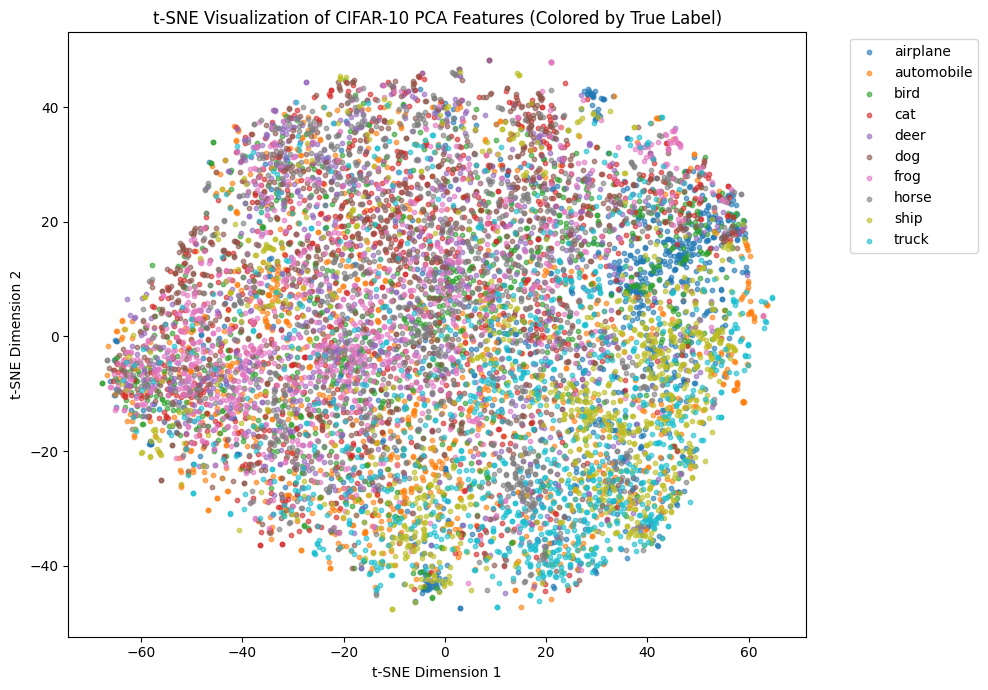

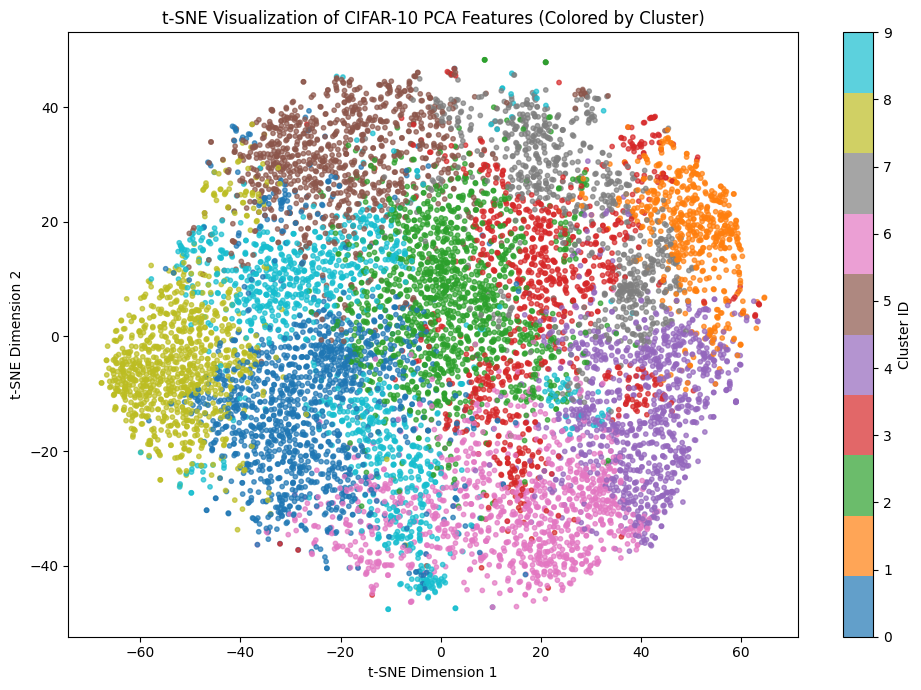

In [6]:
# Use t-SNE on the PCA representation instead of raw pixels.
# This is faster and usually produces cleaner visual structure.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE,
)

X_tsne = tsne.fit_transform(X_unsup_pca)

# Plot the t-SNE embedding colored by true labels.
plt.figure(figsize=(10, 7))
for class_id, class_name in enumerate(class_names):
    mask = y_unsup == class_id
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=10,
        alpha=0.6,
        label=class_name,
    )

plt.title('t-SNE Visualization of CIFAR-10 PCA Features (Colored by True Label)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot the same embedding colored by K-Means cluster assignment.
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_ids,
    cmap='tab10',
    s=10,
    alpha=0.7,
)

plt.title('t-SNE Visualization of CIFAR-10 PCA Features (Colored by Cluster)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster ID')
plt.tight_layout()
plt.show()

## Part 4 - Semi-Supervised Experiment (3%)

To simulate the semi-supervised setting, I use only **10% labeled samples** and treat the rest of the training set as unlabeled. Then I compare three cases:

1. **Limited supervised learning** using only the 10% labeled subset  
2. **Semi-supervised learning with pseudo-labeling**  
3. **Fully supervised learning** using the complete labeled subset used in the experiment

For this part, I use a simple and interpretable classifier on top of PCA features. This keeps the focus on the semi-supervised idea itself rather than on spending a large amount of training time on a deep neural network. The goal is to show that unlabeled data can still be useful when the model is confident enough to generate pseudo-labels.

Labeled subset size: 1000
Unlabeled subset size: 9000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Number of pseudo-labeled samples used: 728


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy with only 10% labeled data: 0.2880
Accuracy with pseudo-labeling:      0.2880
Accuracy with full supervision:     0.3755


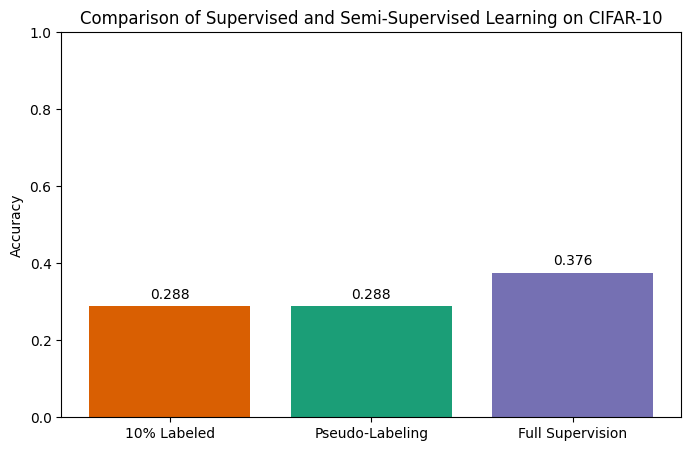

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Build balanced train and test subsets so every class is represented equally.
X_train_ssl, y_train_ssl = build_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=1000,
    random_state=RANDOM_STATE,
)

X_test_ssl, y_test_ssl = build_balanced_subset(
    X_test_full,
    y_test_full,
    samples_per_class=200,
    random_state=RANDOM_STATE,
)

# Flatten the images for a classical machine learning pipeline.
X_train_ssl_flat = X_train_ssl.reshape(len(X_train_ssl), -1).astype(np.float32)
X_test_ssl_flat = X_test_ssl.reshape(len(X_test_ssl), -1).astype(np.float32)

# Fit preprocessing only on the training data to avoid information leakage.
scaler_ssl = StandardScaler()
X_train_ssl_scaled = scaler_ssl.fit_transform(X_train_ssl_flat)
X_test_ssl_scaled = scaler_ssl.transform(X_test_ssl_flat)

# Reduce the feature dimensionality before classification.
pca_ssl = PCA(n_components=100, random_state=RANDOM_STATE)
X_train_ssl_pca = pca_ssl.fit_transform(X_train_ssl_scaled)
X_test_ssl_pca = pca_ssl.transform(X_test_ssl_scaled)

# Split the training subset into a small labeled part and a large unlabeled part.
X_labeled, X_unlabeled, y_labeled, y_unlabeled_true = train_test_split(
    X_train_ssl_pca,
    y_train_ssl,
    test_size=0.90,
    stratify=y_train_ssl,
    random_state=RANDOM_STATE,
)

print('Labeled subset size:', X_labeled.shape[0])
print('Unlabeled subset size:', X_unlabeled.shape[0])

# Train a baseline model with only the 10% labeled data.
limited_supervised_model = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
limited_supervised_model.fit(X_labeled, y_labeled)
limited_preds = limited_supervised_model.predict(X_test_ssl_pca)
limited_acc = accuracy_score(y_test_ssl, limited_preds)

# Generate pseudo-labels for unlabeled data.
unlabeled_proba = limited_supervised_model.predict_proba(X_unlabeled)
pseudo_confidence = unlabeled_proba.max(axis=1)
pseudo_labels = unlabeled_proba.argmax(axis=1)

# Keep only high-confidence pseudo-labels to reduce error propagation.
confidence_threshold = 0.95
high_conf_mask = pseudo_confidence >= confidence_threshold

# If too few samples pass the threshold, keep the top 20% most confident ones.
if high_conf_mask.sum() < 200:
    cutoff = np.quantile(pseudo_confidence, 0.80)
    high_conf_mask = pseudo_confidence >= cutoff

X_pseudo = X_unlabeled[high_conf_mask]
y_pseudo = pseudo_labels[high_conf_mask]

print('Number of pseudo-labeled samples used:', len(X_pseudo))

# Merge the original labeled set with the confident pseudo-labeled samples.
X_semi = np.vstack([X_labeled, X_pseudo])
y_semi = np.concatenate([y_labeled, y_pseudo])

semi_supervised_model = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
semi_supervised_model.fit(X_semi, y_semi)
semi_preds = semi_supervised_model.predict(X_test_ssl_pca)
semi_acc = accuracy_score(y_test_ssl, semi_preds)

# Train a fully supervised reference model using all available labels in the training subset.
fully_supervised_model = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE,
)
fully_supervised_model.fit(X_train_ssl_pca, y_train_ssl)
full_preds = fully_supervised_model.predict(X_test_ssl_pca)
full_acc = accuracy_score(y_test_ssl, full_preds)

print(f'Accuracy with only 10% labeled data: {limited_acc:.4f}')
print(f'Accuracy with pseudo-labeling:      {semi_acc:.4f}')
print(f'Accuracy with full supervision:     {full_acc:.4f}')

# Visualize the comparison in a simple bar chart.
experiment_names = ['10% Labeled', 'Pseudo-Labeling', 'Full Supervision']
experiment_scores = [limited_acc, semi_acc, full_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(experiment_names, experiment_scores, color=['#d95f02', '#1b9e77', '#7570b3'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Comparison of Supervised and Semi-Supervised Learning on CIFAR-10')

for bar, score in zip(bars, experiment_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f'{score:.3f}', ha='center')

plt.show()

## Part 5 - Reflection (1%)

**Advantages of semi-supervised learning**  
One important advantage of semi-supervised learning is that it reduces the need for large labeled datasets, which are usually expensive and time-consuming to create. Another advantage is that it can improve generalization by using unlabeled samples to better capture the structure of the input distribution. In many practical cases, unlabeled data is abundant while labeled data is limited, so semi-supervised methods provide a useful balance between performance and labeling cost.

**When these methods are useful**  
These methods are especially useful in real-world problems such as medical imaging, remote sensing, speech analysis, and large-scale image classification, where collecting raw data is relatively easy but obtaining reliable labels requires human experts. They are also helpful in early project stages, where only a small amount of labeled data is available. Overall, semi-supervised learning is a practical strategy whenever unlabeled data is plentiful and the model can extract meaningful structure from it.